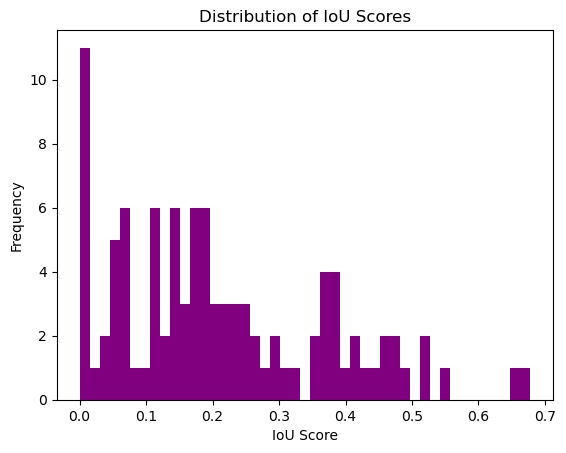

In [11]:
import flammkuchen
import numpy as np
import matplotlib.pyplot as plt

data = flammkuchen.load('rectangles_dsss.sec')
gt_rectangles = np.array(data['ground_truth'])
pred_rectangles = np.array(data['predicted'])

def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    intersection_x1 = max(x1, x2)
    intersection_y1 = max(y1, y2)
    intersection_x2 = min(x1 + w1, x2 + w2)
    intersection_y2 = min(y1 + h1, y2 + h2)
    intersection_area = max(0, intersection_x2 - intersection_x1) * max(0, intersection_y2 - intersection_y1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - intersection_area
    iou = intersection_area / union_area if union_area > 0 else 0
    return iou

ious = []
for i in range(len(gt_rectangles)):
    iou = calculate_iou(gt_rectangles[i], pred_rectangles[i])
    ious.append(iou)

# Plot histogram of IoU scores
plt.hist(ious, bins=45, color = 'purple')
plt.xlabel('IoU Score')
plt.ylabel('Frequency')
plt.title('Distribution of IoU Scores')
plt.show()

Image shape: (512, 256, 3)
Mask shape: (512, 256)
Random Image Filename: 94.png
Random Mask Filename: 94_seg.png


C:\Users\aditya\AppData\Local\Temp\ipykernel_2748\952527649.py:72: UserWarning: Argument 'alpha_affine' is not valid and will be ignored.
  A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),


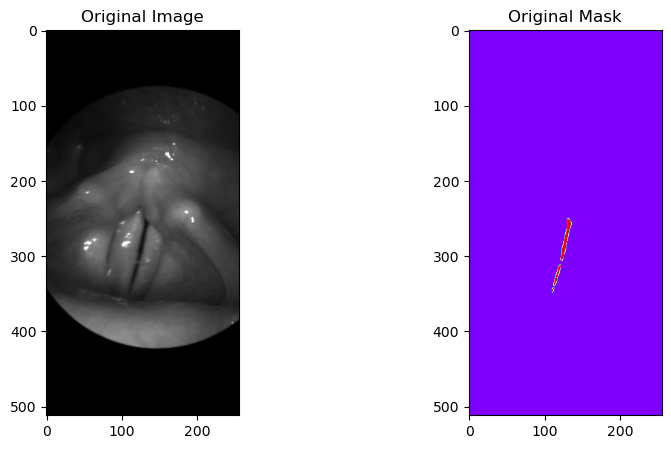

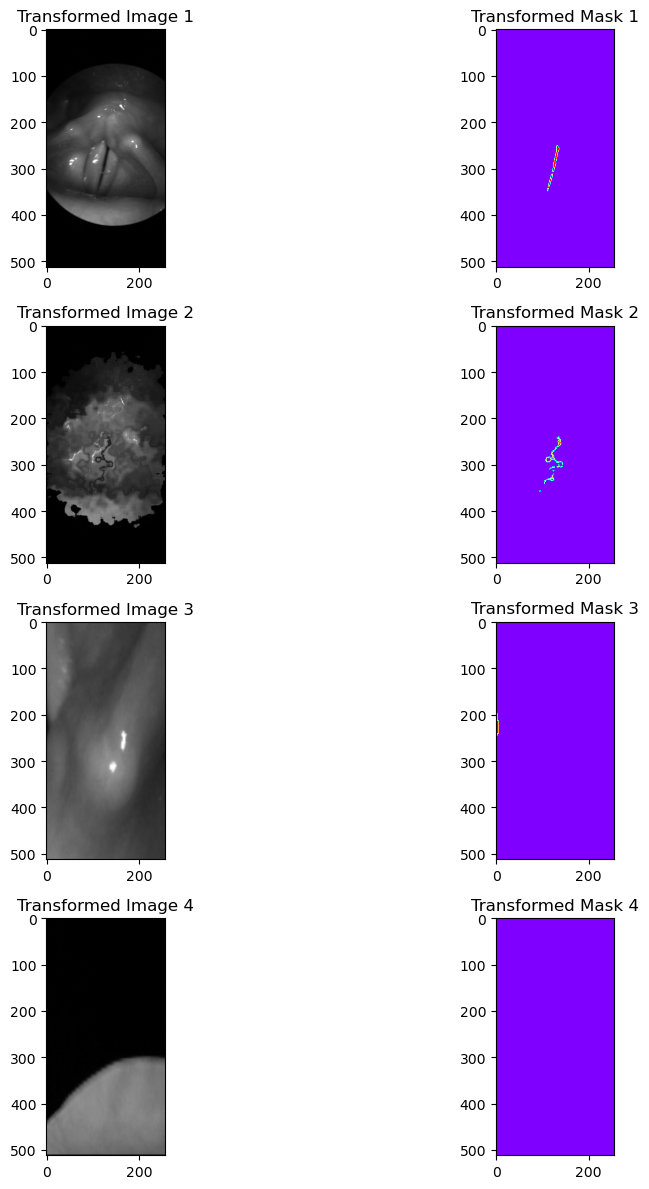

In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
import random

# Setting my matriculation number as the seed
matriculation_number = 23472036  # Randomly chosen Matriculation number
np.random.seed(matriculation_number)
random.seed(11)  # For random module seed setting

# Path to the MiniBAGLS dataset
path_dataset = r'C:\MS\Germany\List of universities\FAU Erlangen\Semester 2\Data Science Survival Skills\Homework submission\Homework 6\Mini_BAGLS_dataset'

img_filenames = [f for f in os.listdir(path_dataset) if f.endswith(".png")]
mask_filenames = [f"{f[:-4]}_seg.png" for f in img_filenames]  # Generate mask filenames based on image filenames

# Select a random image and its releavnt mask
random_index = np.random.choice(len(img_filenames))
random_image_filename = img_filenames[random_index]
random_mask_filename = mask_filenames[random_index]

# Load the random image and mask
image = cv2.imread(os.path.join(path_dataset, random_image_filename))
mask = cv2.imread(os.path.join(path_dataset, random_mask_filename), cv2.IMREAD_UNCHANGED)  # Keep alpha channel if present

# Extract the height and width of the original image
original_height, original_width, _ = image.shape

# Check image and mask shapes
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")

# Check loaded image and mask filenames
print(f"Random Image Filename: {random_image_filename}")
print(f"Random Mask Filename: {random_mask_filename}")

# Define the visualize function
def visualize(image, mask, original_image=None, original_mask=None):
    fontsize = 18
    
    if original_image is None and original_mask is None:
        f, ax = plt.subplots(2, 1, figsize=(8, 8))

        ax[0].imshow(image)
        ax[1].imshow(mask)
    else:
        f, ax = plt.subplots(2, 2, figsize=(8, 8))

        ax[0, 0].imshow(original_image)
        ax[0, 0].set_title('Original image', fontsize=fontsize)
        
        ax[1, 0].imshow(original_mask)
        ax[1, 0].set_title('Original mask', fontsize=fontsize)
        
        ax[0, 1].imshow(image)
        ax[0, 1].set_title('Transformed image', fontsize=fontsize)
        
        ax[1, 1].imshow(mask)
        ax[1, 1].set_title('Transformed mask', fontsize=fontsize)

# Your augmentation code
aug = A.Compose([
    A.OneOf([
        A.RandomSizedCrop(min_max_height=(50, 101), height=original_height, width=original_width, p=0.5),
        A.PadIfNeeded(min_height=original_height, min_width=original_width, p=0.5)
    ], p=1),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.OneOf([
        A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
        A.GridDistortion(p=0.5),
        A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=1),
    ], p=0.8)])

#display of the original image with its mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='rainbow')
plt.title('Original Mask')

# Apply the augmentation to the original image and mask multiple times
plt.figure(figsize=(12, 12))
for i in range(4):
    augmented = aug(image=image, mask=mask)
    transformed_image = augmented['image']
    transformed_mask = augmented['mask']
    
    plt.subplot(4, 2, i * 2 + 1)
    plt.imshow(cv2.cvtColor(transformed_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Transformed Image {i + 1}')
    
    plt.subplot(4, 2, i * 2 + 2)
    plt.imshow(transformed_mask, cmap='rainbow')
    plt.title(f'Transformed Mask {i + 1}')

plt.tight_layout()
plt.show()
